In [1]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


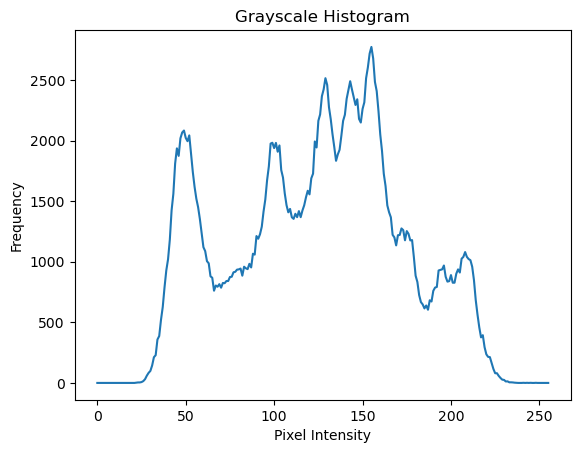

In [53]:
import cv2
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread('lena_gray.jpg', cv2.IMREAD_GRAYSCALE)

# Calculate histogram
hist = cv2.calcHist([img], [0], None, [256], [0, 256])

# Plot histogram
plt.plot(hist)
plt.title('Grayscale Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

# Histogram Equalization


Histogram Equalization Table (First 30 Levels):

 Gray Level (r_k)  No. of Pixels (n_k)  PDF (p_r)  CDF (s_k)  s_k * 255  Equalized Level
                0                    0    0.00000    0.00000       0.00                0
                1                    0    0.00000    0.00000       0.00                0
                2                    0    0.00000    0.00000       0.00                0
                3                    0    0.00000    0.00000       0.00                0
                4                    0    0.00000    0.00000       0.00                0
                5                    0    0.00000    0.00000       0.00                0
                6                    0    0.00000    0.00000       0.00                0
                7                    0    0.00000    0.00000       0.00                0
                8                    0    0.00000    0.00000       0.00                0
                9                    0    0.00000    0.00000

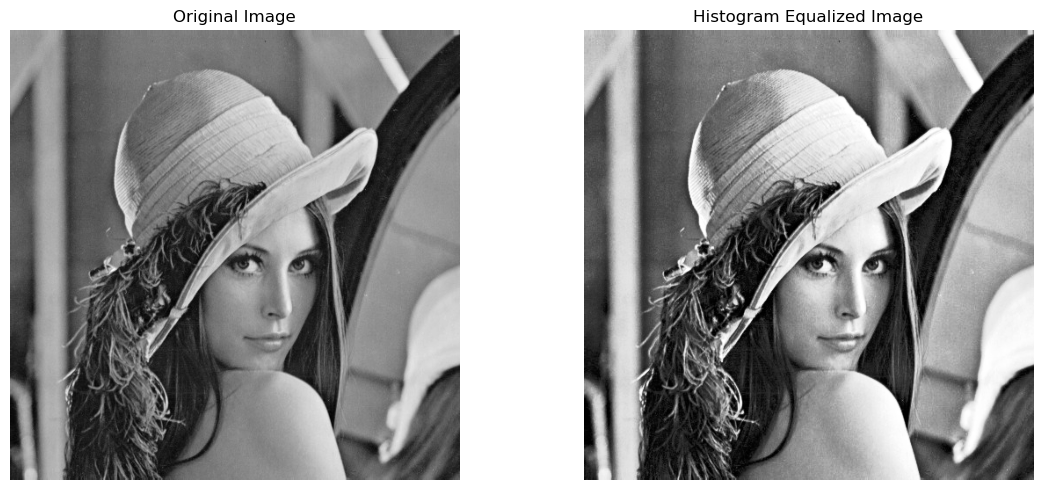

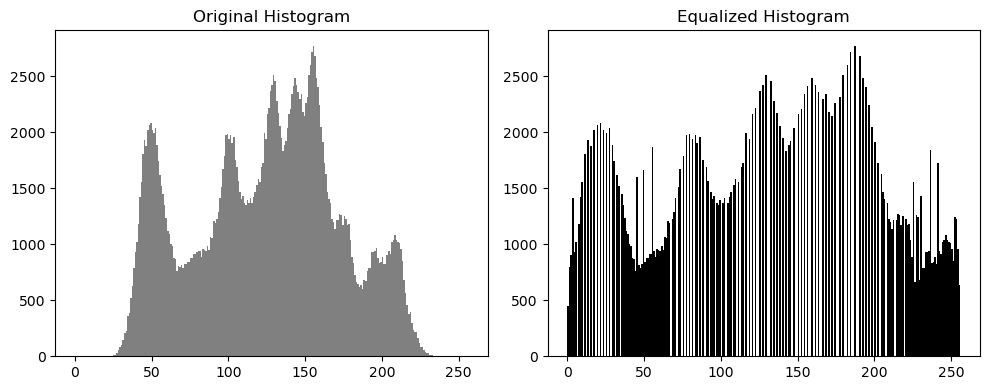

In [ ]:
# Histogram Equalization
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load image in grayscale
img = cv2.imread('lena_gray.jpg', cv2.IMREAD_GRAYSCALE)

# Compute histogram (n_k)
n_k = np.zeros(256, dtype=int)
rows, cols = img.shape

for i in range(rows):
    for j in range(cols):
        pixel_val = img[i, j]
        n_k[pixel_val] += 1

pdf = n_k / float(rows * cols)

# Compute CDF
cdf = np.cumsum(pdf)

#  Equalize levels: round(cdf * (L-1))
equalized_levels = np.round(cdf * 255).astype(np.uint8)

# Table creation and display
data = {
    'Gray Level (r_k)': np.arange(256),
    'No. of Pixels (n_k)': n_k,
    'PDF (p_r)': np.round(pdf, 5),
    'CDF (s_k)': np.round(cdf, 5),
    's_k * 255': np.round(cdf * 255, 2),
    'Equalized Level': equalized_levels
}
df = pd.DataFrame(data)

print("\nHistogram Equalization Table (First 30 Levels):\n")
print(df.head(255).to_string(index=False))

# Map original image to equalized levels
equalized_img = np.zeros_like(img)
for i in range(rows):
    for j in range(cols):
        equalized_img[i, j] = equalized_levels[img[i, j]]

# Display Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_img, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis('off')
plt.tight_layout()
plt.show()

# Show histograms
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=(0, 256), color='gray')
plt.title('Original Histogram')

plt.subplot(1, 2, 2)
plt.hist(equalized_img.ravel(), bins=256, range=(0, 256), color='black')
plt.title('Equalized Histogram')
plt.tight_layout()
plt.show()

In [55]:
img.shape

(512, 512)

# Histogram Matching


In [56]:
img2 = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)


In [57]:
img2 = cv2.resize(img2, (512,512))
img2.shape

(512, 512)


Histogram Equalization Table:

 Gray Level (r_k)  No. of Pixels (n_k)  PDF (p_r)  CDF (s_k)  s_k * 255  Equalized Level
                0                    1    0.00000    0.00000       0.00                0
                1                    0    0.00000    0.00000       0.00                0
                2                    9    0.00003    0.00004       0.01                0
                3                   25    0.00010    0.00013       0.03                0
                4                   75    0.00029    0.00042       0.11                0
                5                  186    0.00071    0.00113       0.29                0
                6                  632    0.00241    0.00354       0.90                1
                7                 1529    0.00583    0.00937       2.39                2
                8                 2788    0.01064    0.02001       5.10                5
                9                 3730    0.01423    0.03424       8.73       

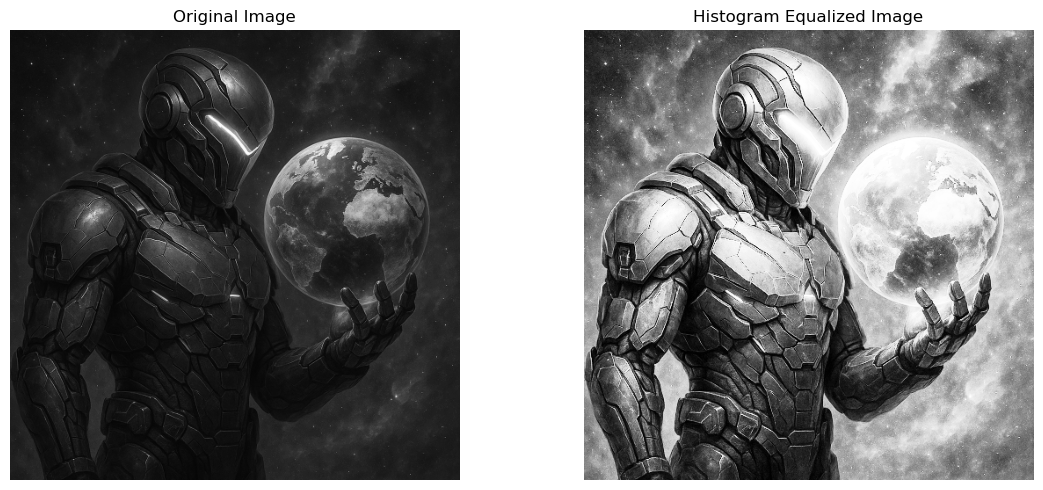

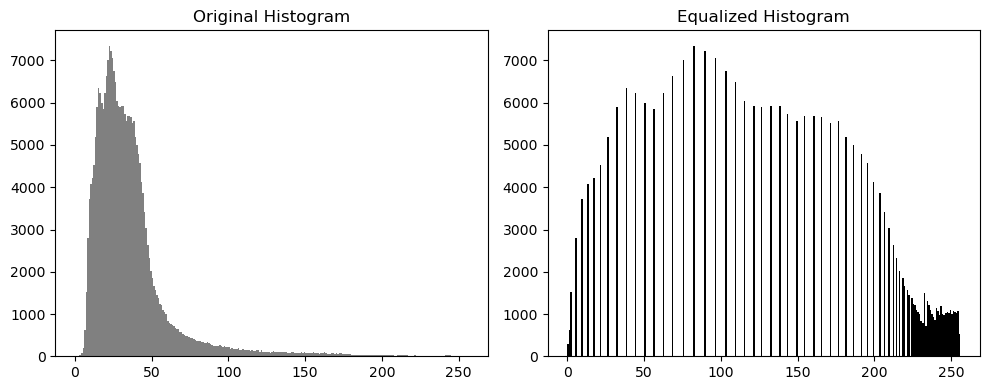

In [ ]:
# Histogram matching
# Compute histogram (n_k)
n_k = np.zeros(256, dtype=int)
rows, cols = img2.shape

for i in range(rows):
    for j in range(cols):
        pixel_val = img2[i, j]
        n_k[pixel_val] += 1

pdf = n_k / float(rows * cols)

# Compute CDF
cdf = np.cumsum(pdf)

#  Equalize levels: round(cdf * (L-1))
equalized_levels2 = np.round(cdf * 255).astype(np.uint8)

# Table creation and display
data = {
    'Gray Level (r_k)': np.arange(256),
    'No. of Pixels (n_k)': n_k,
    'PDF (p_r)': np.round(pdf, 5),
    'CDF (s_k)': np.round(cdf, 5),
    's_k * 255': np.round(cdf * 255, 2),
    'Equalized Level': equalized_levels2
}
df = pd.DataFrame(data)

print("\nHistogram Equalization Table:\n")
print(df.head(255).to_string(index=False))

# Map original image to equalized levels
equalized_img2 = np.zeros_like(img2)
for i in range(rows):
    for j in range(cols):
        equalized_img2[i, j] = equalized_levels2[img2[i, j]]

# Display Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img2, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_img2, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis('off')
plt.tight_layout()
plt.show()

# Show histograms
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(img2.ravel(), bins=256, range=(0, 256), color='gray')
plt.title('Original Histogram')

plt.subplot(1, 2, 2)
plt.hist(equalized_img2.ravel(), bins=256, range=(0, 256), color='black')
plt.title('Equalized Histogram')
plt.tight_layout()
plt.show()

In [59]:
img2.shape

(512, 512)

In [60]:
s1 = equalized_levels 
s2 = equalized_levels2

mapping_result = np.zeros(256, dtype=np.uint8)

for r in range(256):
    diff = np.abs(s1[r] - s2)
    min_index = np.argmin(diff)
    mapping_result[r] = min_index

# Convert to DataFrame for display
data = {
    'Gray Level (r_k)': np.arange(256),
    'Sk1': equalized_levels,
    'Sk2': equalized_levels2,
    'Mapped Level': mapping_result
}
mapping_df = pd.DataFrame(data)
print("\nMapping of Histogram Specified Pixels (First 30 Gray Levels):")
print(mapping_df.head(255).to_string(index=False))



Mapping of Histogram Specified Pixels (First 30 Gray Levels):
 Gray Level (r_k)  Sk1  Sk2  Mapped Level
                0    0    0             0
                1    0    0             0
                2    0    0             0
                3    0    0             0
                4    0    0             0
                5    0    0             0
                6    0    1             0
                7    0    2             0
                8    0    5             0
                9    0    9             0
               10    0   13             0
               11    0   17             0
               12    0   21             0
               13    0   26             0
               14    0   32             0
               15    0   38             0
               16    0   44             0
               17    0   50             0
               18    0   56             0
               19    0   62             0
               20    0   68             0
             

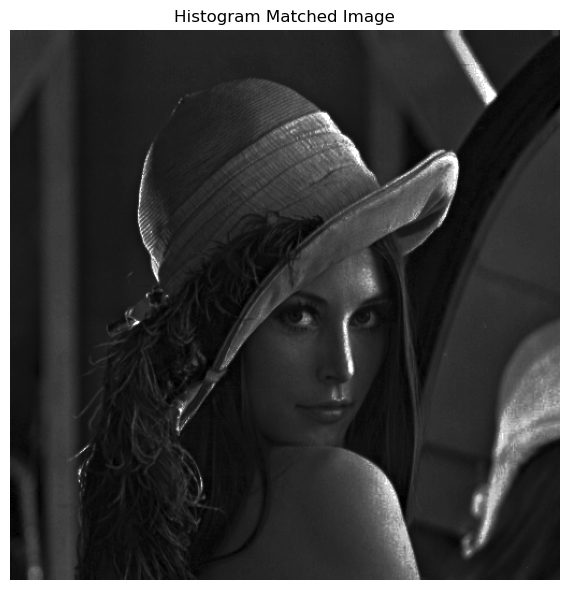

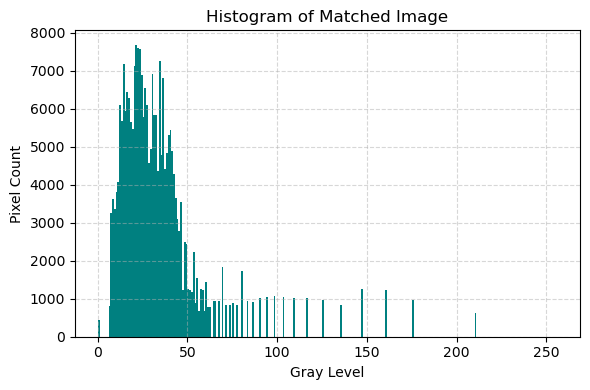

In [61]:
matched_img = mapping_result[img]

# Plot the matched image
plt.figure(figsize=(6, 6))
plt.imshow(matched_img, cmap='gray')
plt.title("Histogram Matched Image")
plt.axis('off')
plt.tight_layout()
plt.show()

# Plot histogram of matched image
plt.figure(figsize=(6, 4))
plt.hist(matched_img.ravel(), bins=256, range=(0, 256), color='teal')
plt.title('Histogram of Matched Image')
plt.xlabel('Gray Level')
plt.ylabel('Pixel Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()